# Mixture Models and the EM Algorithm

| Tutorial status | Details |
|---|---|
| **Course role** | Core bridge from independent latent variables to variational inference |
| **Expected runtime** | Under 2 minutes |
| **Hardware** | CPU |
| **External data** | None |
| **Validation** | Self-contained synthetic workflow |

Mixture models are the first setting in which posterior uncertainty over a
latent variable changes how we learn model parameters. This notebook develops
the sequence

$$
\text{hard assignments} \longrightarrow \text{responsibilities}
\longrightarrow \text{EM} \longrightarrow \text{ELBO}
\longrightarrow \text{stochastic EM}.
$$

This material expands the brief mixture example in
`02_probabilistic_modeling.ipynb` and supplies the conceptual foundation for
CAVI in notebook 05 and HMM inference in notebook 03a.

## 1. Why latent clusters?

Unsupervised learning needs structural constraints. Five useful questions are:

| Constraint | Question |
|---|---|
| Dimensionality | How many clusters or factors are present? |
| Domain | Are latent variables discrete, continuous, sparse, or bounded? |
| Dynamics | Are latent variables independent or temporally coupled? |
| Dependencies | How do latent and observed variables interact? |
| Distribution | Which probability model encodes prior knowledge? |

A Gaussian mixture model chooses a discrete latent domain, independent samples,
and Gaussian conditional distributions.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Ellipse
from scipy.special import logsumexp

plt.rcParams.update({
    "figure.dpi": 120,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.titleweight": "bold",
})
rng = np.random.default_rng(12)

## 2. Gaussian mixture model

For observations $\mathbf{x}_n\in\mathbb{R}^D$ and assignments
$z_n\in\{1,\ldots,K\}$,

$$
z_n \sim \operatorname{Categorical}(\boldsymbol{\pi}),
\qquad
\mathbf{x}_n \mid z_n=k
\sim \mathcal{N}(\boldsymbol{\mu}_k,\boldsymbol{\Sigma}_k).
$$

The marginal density is a weighted sum,

$$
p(\mathbf{x}_n;\boldsymbol{\theta})
=\sum_{k=1}^K \pi_k
\mathcal{N}(\mathbf{x}_n;\boldsymbol{\mu}_k,\boldsymbol{\Sigma}_k).
$$

Unlike a classifier, the model does not observe the cluster labels. It must
infer assignments and estimate parameters jointly.

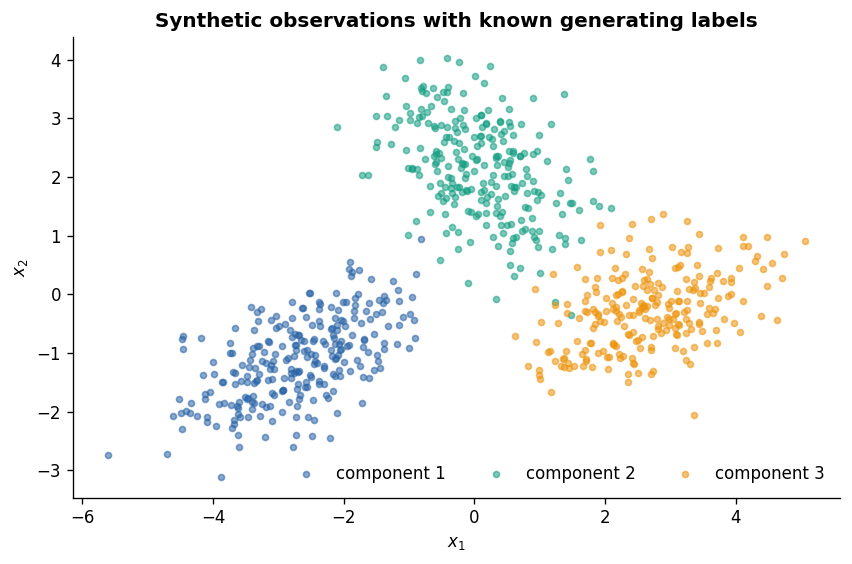

In [2]:
true_weights = np.array([0.34, 0.38, 0.28])
true_means = np.array([[-2.6, -1.0], [0.1, 2.2], [2.7, -0.3]])
true_covariances = np.array([
    [[0.70, 0.28], [0.28, 0.45]],
    [[0.55, -0.20], [-0.20, 0.70]],
    [[0.65, 0.18], [0.18, 0.50]],
])

num_samples = 750
z_true = rng.choice(3, size=num_samples, p=true_weights)
x = np.vstack([
    rng.multivariate_normal(true_means[k], true_covariances[k])
    for k in z_true
])

colors = np.array([[0.16, 0.39, 0.65], [0.08, 0.62, 0.51], [0.93, 0.58, 0.05]])
fig, ax = plt.subplots(figsize=(7.2, 4.8))
for k in range(3):
    ax.scatter(*x[z_true == k].T, s=13, alpha=0.55, color=colors[k], label=f"component {k + 1}")
ax.set(xlabel="$x_1$", ylabel="$x_2$", title="Synthetic observations with known generating labels")
ax.legend(frameon=False, ncol=3)
plt.tight_layout()

## 3. Hard assignments and K-means

Coordinate ascent on the joint probability alternates between a most likely
assignment and parameter updates. With equal spherical covariance matrices and
equal mixture weights, the assignment rule reduces to choosing the closest
mean. This is K-means.

Hard assignment discards ambiguity. A point near a boundary is treated exactly
like a point at the center of a cluster. EM instead retains a probability for
every possible assignment.

## 4. EM uses posterior responsibilities

The E-step computes

$$
r_{nk}
=p(z_n=k\mid\mathbf{x}_n;\boldsymbol{\theta})
=\frac{\pi_k\,\mathcal{N}(\mathbf{x}_n;\boldsymbol{\mu}_k,\boldsymbol{\Sigma}_k)}
{\sum_{j=1}^K\pi_j\,\mathcal{N}(\mathbf{x}_n;\boldsymbol{\mu}_j,\boldsymbol{\Sigma}_j)}.
$$

The M-step forms weighted sufficient statistics,

$$
N_k=\sum_n r_{nk},\qquad
\boldsymbol{\mu}_k=\frac{1}{N_k}\sum_n r_{nk}\mathbf{x}_n,
$$

$$
\boldsymbol{\Sigma}_k
=\frac{1}{N_k}\sum_n r_{nk}
(\mathbf{x}_n-\boldsymbol{\mu}_k)(\mathbf{x}_n-\boldsymbol{\mu}_k)^\top,
\qquad
\pi_k=\frac{N_k}{N}.
$$

In [3]:
def log_gaussian_density(data, means, covariances):
    n, d = data.shape
    values = np.empty((n, len(means)))
    for k, (mean, covariance) in enumerate(zip(means, covariances)):
        difference = data - mean
        sign, log_determinant = np.linalg.slogdet(covariance)
        assert sign > 0
        quadratic = np.einsum(
            "nd,nd->n", difference, np.linalg.solve(covariance, difference.T).T
        )
        values[:, k] = -0.5 * (d * np.log(2 * np.pi) + log_determinant + quadratic)
    return values


def e_step(data, weights, means, covariances):
    log_joint = np.log(weights)[None, :] + log_gaussian_density(data, means, covariances)
    log_normalizer = logsumexp(log_joint, axis=1)
    responsibilities = np.exp(log_joint - log_normalizer[:, None])
    return responsibilities, log_normalizer.sum()


def m_step(data, responsibilities, covariance_floor=1e-5):
    counts = responsibilities.sum(axis=0) + 1e-12
    weights = counts / len(data)
    means = responsibilities.T @ data / counts[:, None]
    covariances = []
    for k in range(responsibilities.shape[1]):
        difference = data - means[k]
        covariance = np.einsum(
            "n,ni,nj->ij", responsibilities[:, k], difference, difference
        ) / counts[k]
        covariances.append(covariance + covariance_floor * np.eye(data.shape[1]))
    return weights, means, np.asarray(covariances)


def fit_gmm(data, num_components, num_iterations=35, seed=0):
    local_rng = np.random.default_rng(seed)
    initial_indices = local_rng.choice(len(data), num_components, replace=False)
    weights = np.ones(num_components) / num_components
    means = data[initial_indices].copy()
    global_covariance = np.cov(data.T) + 0.1 * np.eye(data.shape[1])
    covariances = np.repeat(global_covariance[None, :, :], num_components, axis=0)

    log_likelihoods = []
    snapshots = []
    for iteration in range(num_iterations):
        responsibilities, log_likelihood = e_step(data, weights, means, covariances)
        log_likelihoods.append(log_likelihood)
        if iteration in (0, 1, num_iterations - 1):
            snapshots.append((iteration, weights.copy(), means.copy(), covariances.copy()))
        weights, means, covariances = m_step(data, responsibilities)

    responsibilities, final_log_likelihood = e_step(data, weights, means, covariances)
    log_likelihoods.append(final_log_likelihood)
    assert np.all(np.diff(log_likelihoods) >= -1e-6)
    return (weights, means, covariances), responsibilities, np.asarray(log_likelihoods), snapshots

Estimated weights: [0.338 0.31  0.352]
Minimum likelihood increment: 1.8280843505635858e-10


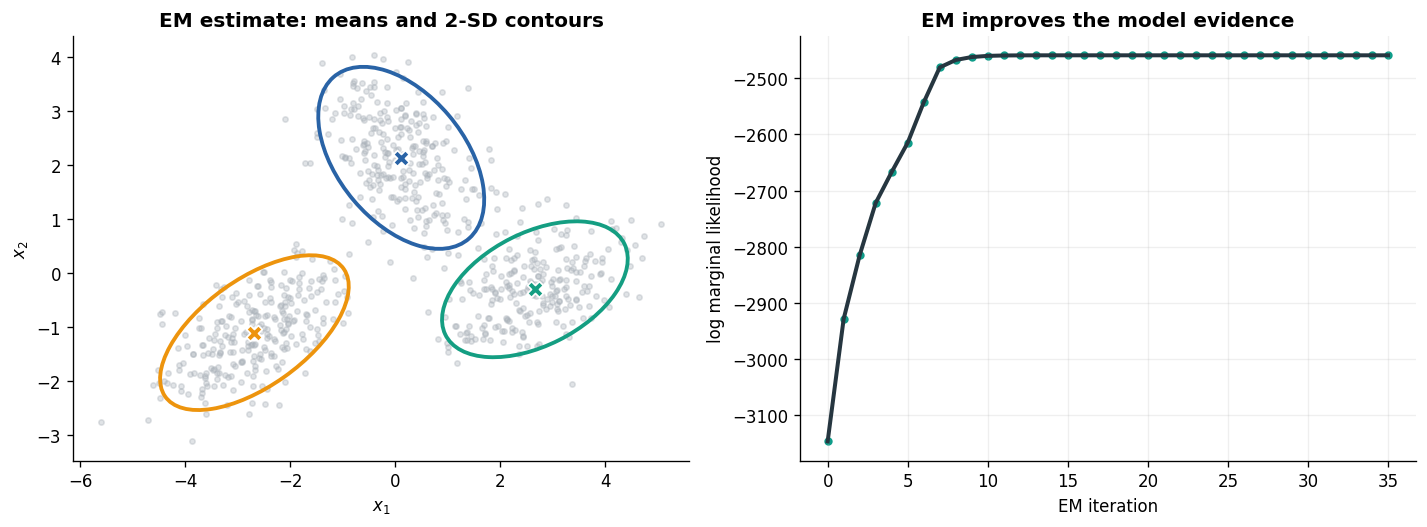

In [4]:
def add_covariance_ellipse(ax, mean, covariance, color, label=None):
    eigenvalues, eigenvectors = np.linalg.eigh(covariance)
    order = np.argsort(eigenvalues)[::-1]
    eigenvalues, eigenvectors = eigenvalues[order], eigenvectors[:, order]
    angle = np.degrees(np.arctan2(eigenvectors[1, 0], eigenvectors[0, 0]))
    ellipse = Ellipse(
        mean,
        width=4 * np.sqrt(eigenvalues[0]),
        height=4 * np.sqrt(eigenvalues[1]),
        angle=angle,
        facecolor="none",
        edgecolor=color,
        linewidth=2.3,
        label=label,
    )
    ax.add_patch(ellipse)


(weights, means, covariances), responsibilities, log_likelihoods, snapshots = fit_gmm(x, 3)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
axes[0].scatter(*x.T, s=10, color="#a8b0b8", alpha=0.35)
for k in range(3):
    add_covariance_ellipse(axes[0], means[k], covariances[k], colors[k])
    axes[0].scatter(*means[k], s=90, marker="X", color=colors[k], edgecolor="white")
axes[0].set(xlabel="$x_1$", ylabel="$x_2$", title="EM estimate: means and 2-SD contours")

axes[1].plot(log_likelihoods, color="#263640", linewidth=2.4)
axes[1].scatter(np.arange(len(log_likelihoods)), log_likelihoods, s=16, color="#0f9d8a")
axes[1].set(xlabel="EM iteration", ylabel="log marginal likelihood", title="EM improves the model evidence")
axes[1].grid(alpha=0.2)
plt.tight_layout()

print("Estimated weights:", np.round(weights, 3))
print("Minimum likelihood increment:", np.diff(log_likelihoods).min())

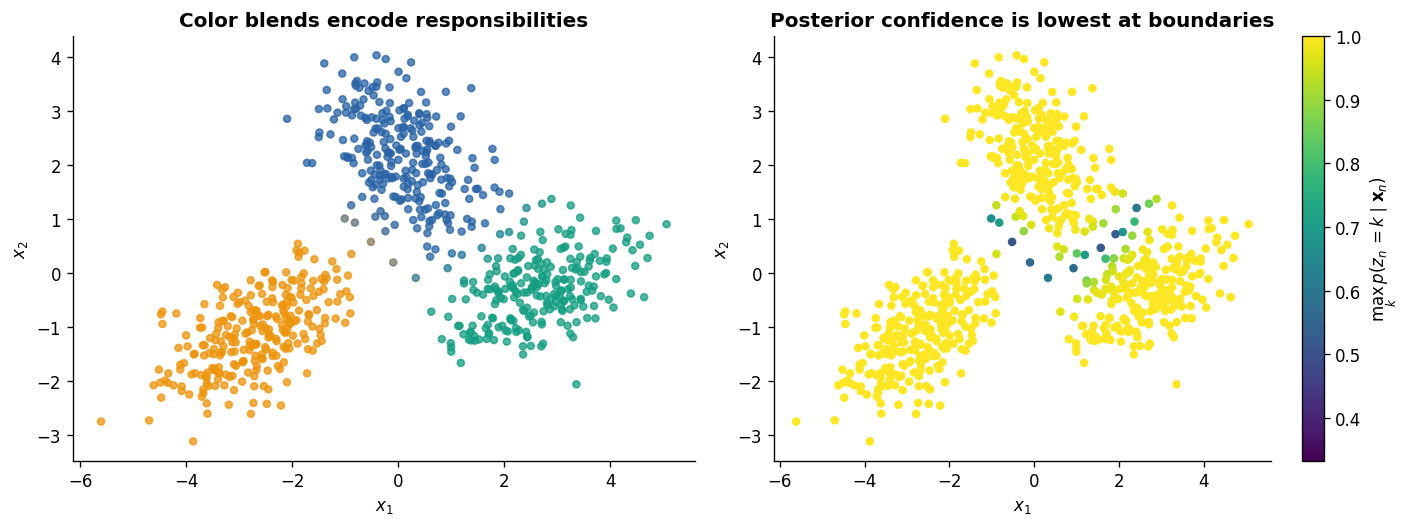

In [5]:
confidence = responsibilities.max(axis=1)
soft_colors = responsibilities @ colors

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
axes[0].scatter(*x.T, c=soft_colors, s=17, alpha=0.75)
axes[0].set(xlabel="$x_1$", ylabel="$x_2$", title="Color blends encode responsibilities")

axes[1].scatter(*x.T, c=confidence, cmap="viridis", s=17, vmin=1 / 3, vmax=1)
axes[1].set(xlabel="$x_1$", ylabel="$x_2$", title="Posterior confidence is lowest at boundaries")
colorbar = fig.colorbar(axes[1].collections[0], ax=axes[1])
colorbar.set_label("$\max_k\,p(z_n=k\mid\mathbf{x}_n)$")
plt.tight_layout()

## 5. EM is coordinate ascent on the ELBO

For any distribution $q(\mathbf{z})$,

$$
\log p(\mathbf{x};\boldsymbol{\theta})
=\mathcal{L}(q,\boldsymbol{\theta})
+\operatorname{KL}\!\left[q(\mathbf{z})\,\|\,
p(\mathbf{z}\mid\mathbf{x};\boldsymbol{\theta})\right],
$$

where

$$
\mathcal{L}(q,\boldsymbol{\theta})
=\mathbb{E}_{q}\!\left[
\log p(\mathbf{x},\mathbf{z};\boldsymbol{\theta})-\log q(\mathbf{z})
\right].
$$

- **E-step:** set $q$ to the exact posterior, making the KL divergence zero.
- **M-step:** maximize the expected complete-data log likelihood with $q$ fixed.

This viewpoint is the direct precursor to variational EM: when the exact
posterior is unavailable, the E-step optimizes within a restricted family.

## 6. Exponential-family mixtures

If component $k$ has exponential-family density

$$
p(\mathbf{x}_n\mid z_n=k;\boldsymbol{\eta}_k)
=h(\mathbf{x}_n)\exp\!\left\{
\langle t(\mathbf{x}_n),\boldsymbol{\eta}_k\rangle
-A(\boldsymbol{\eta}_k)\right\},
$$

then the M-step depends only on

$$
N_k=\sum_n r_{nk},
\qquad
\mathbf{t}_k=\sum_n r_{nk}\,t(\mathbf{x}_n).
$$

This sufficient-statistic view matters because it extends beyond Gaussians and
allows data to be processed in mini-batches.

## 7. Stochastic EM

For a mini-batch $m$, let $\widehat{N}_k^{(m)}$ and
$\widehat{\mathbf{t}}_k^{(m)}$ be normalized sufficient statistics. Maintain
running estimates with

$$
\overline{N}_k\leftarrow(1-\rho_m)\overline{N}_k
+\rho_m\widehat{N}_k^{(m)},
$$

$$
\overline{\mathbf{t}}_k\leftarrow
(1-\rho_m)\overline{\mathbf{t}}_k
+\rho_m\widehat{\mathbf{t}}_k^{(m)}.
$$

A decaying step size lets early batches move the parameters quickly while later
batches stabilize the estimate. Unlike batch EM, the full-data likelihood need
not increase after every mini-batch.

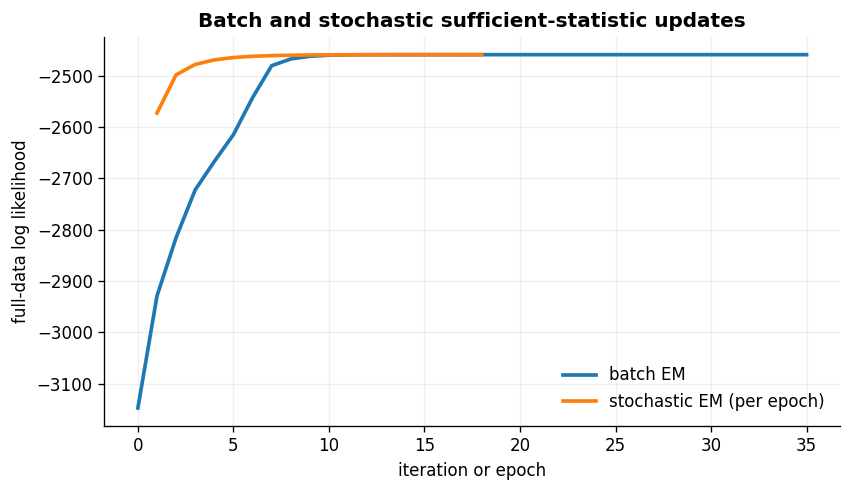

In [6]:
def fit_stochastic_gmm(data, initial_parameters, batch_size=75, epochs=18, seed=4):
    local_rng = np.random.default_rng(seed)
    weights, means, covariances = [value.copy() for value in initial_parameters]
    running_mass = running_first = running_second = None
    likelihoods = []
    step = 0

    for _ in range(epochs):
        for indices in np.array_split(local_rng.permutation(len(data)), len(data) // batch_size):
            batch = data[indices]
            response, _ = e_step(batch, weights, means, covariances)
            mass = response.mean(axis=0)
            first = np.einsum("nk,nd->kd", response, batch) / len(batch)
            second = np.einsum("nk,ni,nj->kij", response, batch, batch) / len(batch)
            rate = (step + 1) ** -0.65
            if running_mass is None:
                running_mass, running_first, running_second = mass, first, second
            else:
                running_mass = (1 - rate) * running_mass + rate * mass
                running_first = (1 - rate) * running_first + rate * first
                running_second = (1 - rate) * running_second + rate * second

            weights = running_mass / running_mass.sum()
            means = running_first / running_mass[:, None]
            covariances = np.asarray([
                running_second[k] / running_mass[k]
                - np.outer(means[k], means[k]) + 1e-4 * np.eye(data.shape[1])
                for k in range(len(weights))
            ])
            step += 1
        likelihoods.append(e_step(data, weights, means, covariances)[1])
    return (weights, means, covariances), np.asarray(likelihoods)


initial = snapshots[0][1:]
_, stochastic_likelihoods = fit_stochastic_gmm(x, initial)

fig, ax = plt.subplots(figsize=(7.2, 4.2))
ax.plot(np.arange(len(log_likelihoods)), log_likelihoods, label="batch EM", linewidth=2.2)
ax.plot(np.arange(1, len(stochastic_likelihoods) + 1), stochastic_likelihoods,
        label="stochastic EM (per epoch)", linewidth=2.2)
ax.set(xlabel="iteration or epoch", ylabel="full-data log likelihood",
       title="Batch and stochastic sufficient-statistic updates")
ax.legend(frameon=False)
ax.grid(alpha=0.2)
plt.tight_layout()

## 8. Bridge to temporal latent variables

The assignments in a mixture model are independent:

$$
p(z_{1:T})=\prod_{t=1}^T p(z_t).
$$

That assumption cannot express persistence, ordered transitions, or recurring
sequential motifs. Notebook `03a_hmm_foundations.ipynb` replaces it with a
Markov chain and shows how dynamic programming preserves tractable inference.

### Takeaways

- Hard assignments lead to K-means-like coordinate ascent.
- Responsibilities preserve posterior uncertainty.
- EM alternates exact posterior inference and parameter optimization.
- The ELBO connects exact EM to later variational methods.
- Sufficient statistics make stochastic and distributed learning possible.